# Linear regression

In [ ]:
import pandas as pd
import torch 

In [ ]:
house = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Boston.csv')

In [ ]:
house.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## First option: training with scikit learn

In [ ]:
y = house['MEDV']
X = house.drop(columns=['MEDV'])

In [ ]:
# Splitting the dataset into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2529)

In [ ]:
# # check shape of train and test sample
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [ ]:
# Select a linear regression model
from sklearn.linear_model import LinearRegression
# Create a linear regression model
model = LinearRegression()

In [ ]:
# Fit the model to the training data
model.fit(X_train, y_train)

LinearRegression()

Mean Squared Error: 20.718012877838557
R-squared: 0.6551914852365515
Coefficients: [-1.29412069e-01  3.65184937e-02  1.54418944e-02  2.35486887e+00
 -2.04171489e+01  4.41356565e+00  4.61075512e-03 -1.58626723e+00
  2.51478665e-01 -9.59591213e-03 -9.64169204e-01  1.00972679e-02
 -5.43198745e-01]
Intercept: 34.21916368863032
First 5 predictions: [31.71733828 22.02143302 21.16613197 39.77837246 20.10258512]
First 5 actual values: [31.5 19.3 19.3 41.7 17.7]


Text(0.5, 1.0, 'Actual vs Predicted Values')

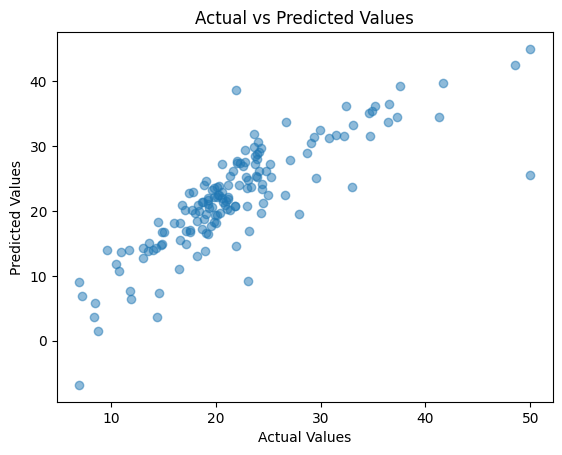

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
# Display the coefficients of the model
print("Coefficients:", model.coef_)
# Display the intercept of the model
print("Intercept:", model.intercept_)
# Display the first 5 predictions
print("First 5 predictions:", y_pred[:5])
# Display the first 5 actual values
print("First 5 actual values:", y_test[:5].values)
# Scatter plot of actual vs predicted values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

## Other option: training with pytorch

In [ ]:
# Training data (making the dataframe into a tensor)

X_torch = torch.tensor(X.values, dtype=torch.float32, requires_grad=True)
y_torch = torch.tensor(y.values, dtype=torch.float32, requires_grad=True)


In [ ]:
print("Shape of X_torch:", X_torch.shape)
print("Shape of y_torch:", y_torch.shape)

Shape of X_torch: torch.Size([506, 13])
Shape of y_torch: torch.Size([506])


In [ ]:
# Defining a weight and bias for a linear model
w = torch.randn(X_torch.shape[1], requires_grad=True)  # Random weights
b = torch.randn(1, requires_grad=True)  # Random bias

print("Initial weights:", w)
print("Shape of weights:", w.shape)
print("Initial bias:", b)

Initial weights: tensor([ 1.8064, -0.5702, -1.0813, -0.6298,  1.5258,  0.9243, -1.2849,  0.5079,
        -0.6512,  0.8787,  0.8845,  2.0484,  0.9840], requires_grad=True)
Shape of weights: torch.Size([13])
Initial bias: tensor([-0.2209], requires_grad=True)


DISCLAIMER : All tensors should be the same dtype. 

In [ ]:
# Defining the linear model
def linear_model(X, w, b):
    return X @ w + b  # Matrix multiplication and addition of bias

In [ ]:
# Generating rubbish predictions
rubbish_predictions = linear_model(X_torch, w, b)

In [ ]:
# Calculating the loss using Mean Squared Error
def mean_squared_error(y_true, y_pred):
    return torch.mean((y_true - y_pred) ** 2)

In [ ]:
loss = mean_squared_error(y_torch, rubbish_predictions)
print("Initial loss:", loss.item())

Initial loss: 1026839.8125


In [ ]:
loss.backward()  # Compute gradients

In [ ]:
w.grad, b.grad  # Access gradients

(tensor([7.5535e+03, 2.2207e+04, 2.2600e+04, 1.3678e+02, 1.1098e+03, 1.2504e+04,
         1.3686e+05, 7.5321e+03, 1.9856e+04, 8.3409e+05, 3.6988e+04, 7.3397e+05,
         2.5378e+04]),
 tensor([1995.1416]))

In [ ]:
### VERY IMPORTANT: Zero the gradients before the next iteration
w.grad.zero_()
b.grad.zero_()  # Zero the gradients for bias

tensor([0.])

Otherwise, calling loss.backward will add the gradients to the existing ones, which is not what we want.

```python

In [ ]:
# Loss was exploding - might be wildly different scales in X
# Normalizing the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)  # Fit and transform the features
X_torch_scaled = torch.tensor(X_scaled, dtype=torch.float32, requires_grad=True)  # Convert to tensor
# Re-initialize weights and bias
w = torch.randn(X_torch_scaled.shape[1], requires_grad=True)  # Random weights
b = torch.randn(1, requires_grad=True)  # Random bias

In [ ]:
#Again
def gradient_descent_step(w, b, X, y, learning_rate=1e-4, verbose=False):
    """Perform a single step of gradient descent with gradient clipping."""
    predictions = linear_model(X, w, b)
    loss = mean_squared_error(y, predictions)
    loss.backward()

    if verbose:
        print(f"Loss before update: {loss.item():.6f}")
        print(f"Weight grad norm: {w.grad.norm():.6f}, Bias grad: {b.grad.item():.6f}")

    # 🚨 Gradient Clipping: prevent exploding gradients
    #torch.nn.utils.clip_grad_norm_([w, b], max_norm=1.0)

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # Optional: Clamp weights to a reasonable range (extra safety)
        #w.clamp_(-10, 10)
        #b.clamp_(-10, 10)

    w.grad.zero_()
    b.grad.zero_()

    if verbose:
        new_loss = mean_squared_error(y, linear_model(X, w, b))
        print(f"Updated weights: {w}")
        print(f"Updated bias: {b}")
        print(f"Loss after update: {new_loss.item():.6f}")

    return w, b


In [ ]:
# Training the model using gradient descent - 100 epochs
for epoch in range(1000):
    w, b = gradient_descent_step(w, b, X_torch_scaled, y_torch, learning_rate=0.01, verbose=(epoch % 10 == 0))

Loss before update: 611.130188
Weight grad norm: 30.442801, Bias grad: -45.986614
Updated weights: tensor([ 0.2437, -0.9938,  0.3028,  2.7226,  1.4381,  2.1959, -0.8103, -0.1774,
         0.6336, -2.0043,  1.3695,  1.7538,  0.1412], requires_grad=True)
Updated bias: tensor([-0.0006], requires_grad=True)
Loss after update: 581.451111
Loss before update: 396.548920
Weight grad norm: 10.853824, Bias grad: -37.574409
Updated weights: tensor([-0.0905, -0.4361, -0.2013,  2.4581,  0.9657,  2.8705, -1.2165,  0.0799,
         0.3445, -2.3493,  0.6726,  1.8372, -0.6477], requires_grad=True)
Updated bias: tensor([4.1213], requires_grad=True)
Loss after update: 381.437073
Loss before update: 272.211121
Weight grad norm: 6.518062, Bias grad: -30.701029
Updated weights: tensor([-0.1700, -0.1963, -0.3227,  2.2284,  0.8473,  3.2397, -1.2827,  0.0071,
         0.3738, -2.3504,  0.2692,  1.7434, -1.0450], requires_grad=True)
Updated bias: tensor([7.4893], requires_grad=True)
Loss after update: 262.46133

In [ ]:
# Works by hand but still a loss
print("Final weights:", w)
print("Final bias:", b)

Final weights: tensor([-8.8738e-01,  1.0162e+00,  1.5896e-03,  6.9994e-01, -1.8933e+00,
         2.7383e+00, -4.5478e-02, -3.0302e+00,  2.3080e+00, -1.7358e+00,
        -2.0154e+00,  8.5713e-01, -3.7061e+00], requires_grad=True)
Final bias: tensor([22.5328], requires_grad=True)


We almost reach the loss from scikit learn, but not quite.

In [ ]:
# Trying with an adam optimizer
import torch.optim as optim
# Initialize the optimizer
optimizer = optim.Adam([w, b], lr=0.01)
# Training the model using Adam optimizer - 100 epochs
for epoch in range(100):
    optimizer.zero_grad()  # Zero the gradients
    predictions = linear_model(X_torch_scaled, w, b)  # Forward pass
    loss = mean_squared_error(y_torch, predictions)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update weights and bias

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 21.894833
Epoch 10, Loss: 21.895378
Epoch 20, Loss: 21.895042
Epoch 30, Loss: 21.894846
Epoch 40, Loss: 21.894855
Epoch 50, Loss: 21.894835
Epoch 60, Loss: 21.894836
Epoch 70, Loss: 21.894835
Epoch 80, Loss: 21.894833
Epoch 90, Loss: 21.894833


Seems we cannot optimize much further.

### Linear regression class - creating an instance of the model

In [ ]:
# Doing it with nn
import torch.nn as nn
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)  # Linear layer # input_dim is the number of features
        # 1 is the output dimension (single target variable), it would be 2 for a 2D output, etc.

    def forward(self, x):
        return self.linear(x)  # Forward pass through the linear layer

In [ ]:
? nn.Linear

Init signature:
 nn.Linear(
    in_features: int,
    out_features: int,
    bias: bool = True,
    device=None,
    dtype=None,
) -> None
Docstring:     
Applies an affine linear transformation to the incoming data: :math:`y = xA^T + b`.

This module supports :ref:`TensorFloat32<tf32_on_ampere>`.

On certain ROCm devices, when using float16 inputs this module will use :ref:`different precision<fp16_on_mi200>` for backward.

Args:
    in_features: size of each input sample
    out_features: size of each output sample
    bias: If set to ``False``, the layer will not learn an additive bias.
        Default: ``True``

Shape:
    - Input: :math:`(*, H_{in})` where :math:`*` means any number of
      dimensions including none and :math:`H_{in} = \text{in\_features}`.
    - Output: :math:`(*, H_{out})` where all but the last dimension
      are the same shape as the input and :math:`H_{out} = \text{out\_features}`.

Attributes:
    weight: the learnable weights of the module of shape
      

In [ ]:
# Create an instance of the model
model_nn = LinearRegressionModel(input_dim=X_torch_scaled.shape[1]) # initialize initt with input dims
# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer_nn = optim.Adam(model_nn.parameters(), lr=0.1)  # Adam optimizer
# Training the model using PyTorch's nn module - 100 epochs
for epoch in range(1000):
    optimizer_nn.zero_grad()  # Zero the gradients
    predictions = model_nn(X_torch_scaled)  # Forward pass # Run the forward pass with the actual data
    loss = criterion(predictions.squeeze(), y_torch)  # Compute loss
    loss.backward()  # Backward pass
    optimizer_nn.step()  # Update weights and bias

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 600.184937
Epoch 10, Loss: 517.189880
Epoch 20, Loss: 463.325897
Epoch 30, Loss: 419.188873
Epoch 40, Loss: 379.693054
Epoch 50, Loss: 344.574036
Epoch 60, Loss: 312.496460
Epoch 70, Loss: 282.924133
Epoch 80, Loss: 255.754135
Epoch 90, Loss: 230.863541
Epoch 100, Loss: 208.121475
Epoch 110, Loss: 187.395691
Epoch 120, Loss: 168.558701
Epoch 130, Loss: 151.487320
Epoch 140, Loss: 136.062363
Epoch 150, Loss: 122.168045
Epoch 160, Loss: 109.692093
Epoch 170, Loss: 98.526291
Epoch 180, Loss: 88.566353
Epoch 190, Loss: 79.712418
Epoch 200, Loss: 71.869034
Epoch 210, Loss: 64.945465
Epoch 220, Loss: 58.855862
Epoch 230, Loss: 53.519291
Epoch 240, Loss: 48.859955
Epoch 250, Loss: 44.807106
Epoch 260, Loss: 41.295170
Epoch 270, Loss: 38.263466
Epoch 280, Loss: 35.656479
Epoch 290, Loss: 33.423309
Epoch 300, Loss: 31.517809
Epoch 310, Loss: 29.898270
Epoch 320, Loss: 28.527170
Epoch 330, Loss: 27.370983
Epoch 340, Loss: 26.399862
Epoch 350, Loss: 25.587381
Epoch 360, Loss: 24.91

### A more hands on way to create the model

```python

In [ ]:
# Another way to do it
model = nn.Linear(X_torch_scaled.shape[1], 1)  # Create a linear model
print("Model parameters:", list(model.parameters()))  # Display model parameters
model.weight, model.bias  # Access weights and bias


Model parameters: [Parameter containing:
tensor([[ 0.0508,  0.1022, -0.1096,  0.0870,  0.1249, -0.2752, -0.1327,  0.1959,
          0.1043, -0.1124,  0.0579,  0.1165, -0.0287]], requires_grad=True), Parameter containing:
tensor([0.1348], requires_grad=True)]


(Parameter containing:
 tensor([[ 0.0508,  0.1022, -0.1096,  0.0870,  0.1249, -0.2752, -0.1327,  0.1959,
           0.1043, -0.1124,  0.0579,  0.1165, -0.0287]], requires_grad=True),
 Parameter containing:
 tensor([0.1348], requires_grad=True))

In [ ]:
predictions = model(X_torch_scaled)  # Forward pass

### Trying to batch the data

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Create a dataset and dataloader
dataset = TensorDataset(X_torch_scaled, y_torch)  

# Create a DataLoader for batching - shuffle=True for random sampling
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

### Using the batching

In [ ]:
import torch.nn.functional as F
# Use a stochastic gradient descent (SGD) optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent optimizer
# Training the model using DataLoader - 100 epochs
for epoch in range(100):
    for batch_X, batch_y in dataloader:  # Iterate over batches
        optimizer.zero_grad()  # Zero the gradients
        predictions = model(batch_X)  # Forward pass
        loss = F.mse_loss(predictions.squeeze(), batch_y)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights and bias

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 22.790081
Epoch 10, Loss: 39.544601
Epoch 20, Loss: 17.799826
Epoch 30, Loss: 14.517787
Epoch 40, Loss: 14.859343
Epoch 50, Loss: 37.533821
Epoch 60, Loss: 21.713793
Epoch 70, Loss: 13.813471
Epoch 80, Loss: 14.107970
Epoch 90, Loss: 16.732666


# Testing all of that on the Boston housing dataset

```python

In [ ]:
train_df = pd.read_csv("train.csv")

In [ ]:
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


## 1. With the scikit learn model

Mean Squared Error: 27.461557462906686
Pearson Correlation Coefficient: 0.840095837013396


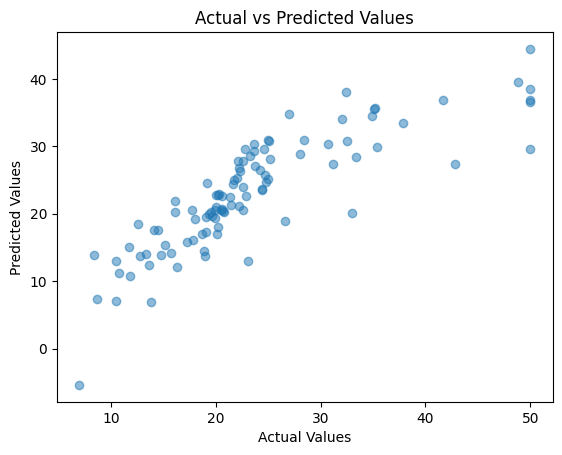

In [ ]:
x = train_df.drop(columns=['medv'])
y = train_df['medv']

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=2529)

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)  # Fit and transform the training data
x_test = scaler.transform(x_test)  # Transform the testing data using the same scaler

# Use linear regression model from sklearn
from sklearn.linear_model import LinearRegression
# Create a linear regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(x_train, y_train)
# Make predictions on the testing set
predictions = model.predict(x_test)
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)

plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
print("Pearson Correlation Coefficient:", np.corrcoef(y_test, predictions)[0, 1])

## 2. With the pytorch model

In [ ]:
# Making the data into a PyTorch tensor
x_train_tensor = torch.tensor(x.values, dtype=torch.float32, requires_grad=True)
y_train_tensor = torch.tensor(y.values, dtype=torch.float32, requires_grad=True)


In [ ]:
# Using the linear model from PyTorch
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)  # Linear layer

    def forward(self, x):
        return self.linear(x)  # Forward pass through the linear layer

# Create an instance of the model
model_nn = LinearRegressionModel(input_dim=x_train_tensor.shape[1])  # Initialize with input dimensions

In [ ]:
# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer_nn = optim.Adam(model_nn.parameters(), lr=0.1)  # Adam optimizer

# Training the model using PyTorch's nn module - with a loop

def step(model, x, y, criterion, optimizer, epsilon=1e-6):
    """Perform a single step of training."""
    optimizer.zero_grad()  # Zero the gradients
    predictions = model(x)  # Forward pass
    loss = criterion(predictions.squeeze(), y)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update weights and bias
    return loss

first_loss = step(model_nn, x_train_tensor, y_train_tensor, criterion, optimizer_nn)
print(f"Initial loss: {first_loss.item():.6f}")
second_loss = step(model_nn, x_train_tensor, y_train_tensor, criterion, optimizer_nn)
print(f"Loss after one step: {second_loss.item():.6f}")

while abs(first_loss.item() - second_loss.item()) > 1e-6:
    first_loss = second_loss
    second_loss = step(model_nn, x_train_tensor, y_train_tensor, criterion, optimizer_nn)
    print(f"Loss: {second_loss.item():.6f}")
# Final loss after convergence
print(f"Final loss after convergence: {second_loss.item():.6f}")

Initial loss: 23.418339
Loss after one step: 2213.724854
Loss: 2431.355713
Loss: 1687.345337
Loss: 225.227310
Loss: 1406.644653
Loss: 1218.812622
Loss: 179.472809
Loss: 439.288208
Loss: 990.713684
Loss: 537.508362
Loss: 73.539696
Loss: 386.091370
Loss: 654.760071
Loss: 324.733917
Loss: 62.248264
Loss: 281.147247
Loss: 439.881744
Loss: 214.360153
Loss: 48.126202
Loss: 199.877960
Loss: 299.838776
Loss: 143.755371
Loss: 43.247665
Loss: 155.327316
Loss: 211.007889
Loss: 96.259758
Loss: 43.519035
Loss: 127.765297
Loss: 145.569565
Loss: 58.766151
Loss: 42.894970
Loss: 104.331047
Loss: 94.223938
Loss: 34.989738
Loss: 47.014946
Loss: 85.428986
Loss: 59.182533
Loss: 28.790646
Loss: 54.081093
Loss: 66.793037
Loss: 37.262409
Loss: 32.174385
Loss: 53.781521
Loss: 45.365627
Loss: 26.384455
Loss: 36.844810
Loss: 44.251678
Loss: 29.018095
Loss: 27.013586
Loss: 38.136967
Loss: 32.388760
Loss: 24.521696
Loss: 31.971003
Loss: 33.197254
Loss: 25.235029
Loss: 27.642229
Loss: 31.696955
Loss: 26.247238
Loss

In [ ]:
# Real test set
test_df = pd.read_csv("test.csv")

# Into a tensor
x_test_tensor = torch.tensor(test_df.values, dtype=torch.float32, requires_grad=False)


In [ ]:
# Using the model to make predictions
predictions = model_nn(x_test_tensor).detach().numpy()  # Forward pass to get predictions

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(predictions, columns=['medv'])
# Save predictions to a CSV file
predictions_df.to_csv('predictions.csv', index=True, index_label='id')  # Save with index as 'id'